# 1. IMPORTS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importación de datasets 

In [3]:
from pathlib import Path

base_dir = 'kdd_datasets - tratados'


def load_all_datasets(base_dir: str = 'kdd_datasets - tratados') -> dict[str, pd.DataFrame]:
    """Carga todos los CSV del directorio y devuelve un diccionario de DataFrames."""
    base_path = Path(base_dir)
    if not base_path.exists():
        raise FileNotFoundError(f'Directorio no encontrado: {base_path}')

    datasets = {
        csv_file.stem: pd.read_csv(csv_file)
        for csv_file in sorted(base_path.glob('*.csv'))
    }
    return datasets


datasets = load_all_datasets(base_dir)

# Asignar variables opcionales para uso directo
for name in [
    'condiciones_climaticas',
    'imagenes_metadata',
    'noticias_agricolas',
    'politicas_agricolas',
    'precios_mercado',
    'produccion_agricola',
    'produccion_ganadera',
    'reportes_plagas',
]:
    globals()[name] = datasets[name]

# Mostrar los tamaños de cada dataset
for name, df in datasets.items():
    print(f'{name}: {df.shape}')


condiciones_climaticas: (256, 13)
imagenes_metadata: (250, 15)
noticias_agricolas: (60, 9)
politicas_agricolas: (148, 13)
precios_mercado: (864, 9)
produccion_agricola: (1200, 11)
produccion_ganadera: (600, 9)
reportes_plagas: (100, 11)


In [4]:
datasets['condiciones_climaticas'].head()

,codigo_iso,pais,regiones_anio,regiones_dias_con_heladas,regiones_eventos_extremos,regiones_humedad_relativa_promedio,regiones_indice_aridez,regiones_meses_estres_hidrico,regiones_nombre,regiones_precipitacion_total,regiones_temperatura_maxima,regiones_temperatura_minima,regiones_temperatura_promedio
0,ARG,Argentina,2017,62,NaN,40,24.06,4,Cuyo,1074,22.5,"0,5",12.4
1,ARG,Argentina,2015,4,NaN,70,19.09,2,Cuyo,873,20.8,"0,9",12.7
2,ARG,Argentina,2019,111,NaN,64,16.19,1,Cuyo,880,29.9,"4,8",15.1
3,ARG,Argentina,2018,64,NaN,68,12.85,0,Cuyo,907,30.6,"6,6",19.6
4,ARG,Argentina,2016,93,NaN,83,29.64,0,Cuyo,1387,22.6,"7,2",13.0


In [5]:
datasets['imagenes_metadata'].head()

,imagen_id,pais,region,fecha,indice_ndvi_promedio,indice_ndvi_min,indice_ndvi_max,indice_evi,uso_suelo_predominante,humedad_suelo_estimada,cobertura_nubes,resolucion_metros,satelite,bandas_disponibles,calidad_imagen
0,SAT_FRA_202001_000,Francia,Región Principal,2020-01-15,0.391,0.259,0.432,0.432,bosque,0.378,0.074,30,MODIS,"RGB, NIR, SWIR",media
1,SAT_ARG_202001_001,Argentina,Noroeste,2020-01-31,0.488,0.390,0.601,0.555,mixto,0.480,0.055,30,Sentinel-2,"RGB, NIR, SWIR",baja
2,SAT_CHN_202003_002,China,Región Principal,2020-03-01,0.546,0.433,0.622,0.655,urbano,0.552,0.099,20,MODIS,"RGB, NIR, SWIR",baja
3,SAT_DEU_202003_003,Alemania,Región Principal,2020-03-12,0.601,0.446,0.655,0.744,urbano,0.644,0.209,60,Sentinel-2,"RGB, NIR, SWIR",media
4,SAT_FRA_202003_004,Francia,Región Principal,2020-03-22,0.639,0.518,0.753,0.792,mixto,0.441,0.249,10,Sentinel-2,"RGB, NIR, SWIR",baja


# 3. Análisis exploratorio por tipo de datos


### 3.1 ¿Cómo se relaciona el uso de fertilizantes con el rendimiento?

##### Primero, generamos un dataset con los datos a estudiar

In [6]:
fertilizante_rendimiento = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'fertilizantes_kg_ha', 'rendimiento_ton_ha']
].dropna()

fertilizante_rendimiento.head()

,pais,region,cultivo,anio,fertilizantes_kg_ha,rendimiento_ton_ha
0,Argentina,América del Sur,Soja,2011,105,2.22
1,Argentina,América del Sur,Maíz,2011,164,8.45
2,Argentina,América del Sur,Cebada,2011,105,2.77
3,Argentina,América del Sur,Té,2011,236,3.07
4,Argentina,América del Sur,Algodón,2011,276,1.18


##### Comprobamos que no haya nulos

In [7]:
fertilizante_rendimiento.isna().sum()

pais                   0
region                 0
cultivo                0
anio                   0
fertilizantes_kg_ha    0
rendimiento_ton_ha     0
dtype: int64

##### Al hacer el gráfico de correlación entre fertilizante y rendimiento se puede comprobar como no existe casi ninguna correlación entre ambos. Esto quiere decir que los cambios en las cantidades de fertilizantes usados no parecen tener ningún efecto en el crecimiento de los cultivos

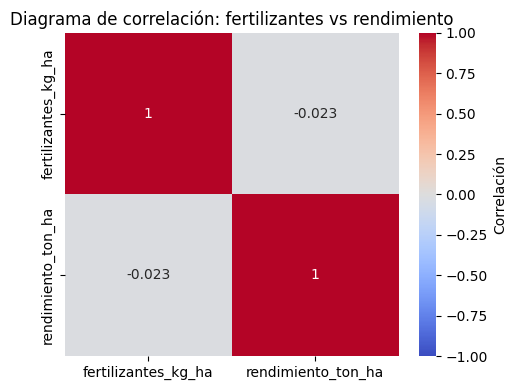

In [8]:
corr_matrix = fertilizante_rendimiento[['fertilizantes_kg_ha', 'rendimiento_ton_ha']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Diagrama de correlación: fertilizantes vs rendimiento')
plt.tight_layout()
plt.show()

##### En el caso del scatterplot donde se muestra la relación previa teniendo en cuenta los distintos cultivos, se puede ver que el rendimiento de la caña de azucar excede por bastante al resto de cultivos, que parecen tener un rendimiento casi nulo. Esto podría ser porque el uso de fertilizantes si que ayuda y aporta al crecimiento de la caña, mientras que al resto no les mejora tanto y por eso la relación previa es baja.

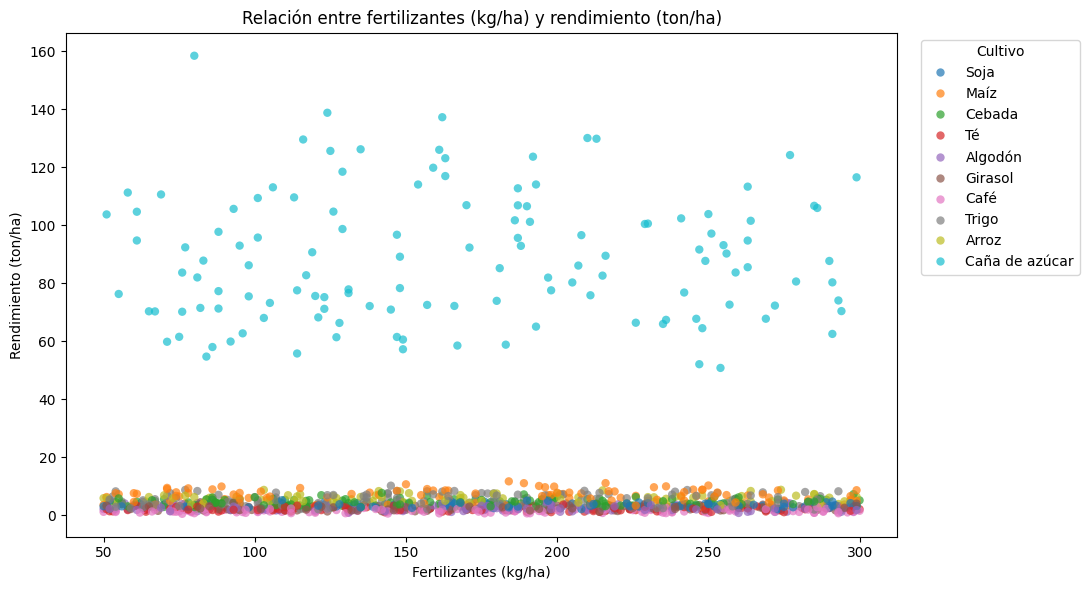

In [9]:
plt.figure(figsize=(11, 6))
sns.scatterplot(
    data=fertilizante_rendimiento,
    x='fertilizantes_kg_ha',
    y='rendimiento_ton_ha',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.title('Relación entre fertilizantes (kg/ha) y rendimiento (ton/ha)')
plt.xlabel('Fertilizantes (kg/ha)')
plt.ylabel('Rendimiento (ton/ha)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Haciendo un análisis mas exhaustivo de la correlación que hay con cada cultivo, hemos visto que en realidad en el caso de la caña no hay un patrón claro con los estudios previos. Es decir, si bien su rendimiento es superior al resto de cultivos, su correlación con la cantidad de fertilizante y rendimiento es bastante baja por lo que no podemos afirmar que su "alto" rendimiento se deba a ello.

In [22]:
corr_por_cultivo_fertilizante = []
for cultivo, grupo in fertilizante_rendimiento.groupby('cultivo'):
    corr = grupo['fertilizantes_kg_ha'].corr(grupo['rendimiento_ton_ha'])
    corr_por_cultivo_fertilizante.append({'cultivo': cultivo, 'correlacion': corr, 'muestras': len(grupo)})

corr_por_cultivo_fertilizante = pd.DataFrame(corr_por_cultivo_fertilizante).sort_values('correlacion', ascending=False)
print(corr_por_cultivo_fertilizante)

          cultivo  correlacion  muestras
4          Cebada     0.119962       140
2            Café     0.085235       130
5         Girasol     0.051202       120
3  Caña de azúcar     0.016324       130
7            Soja     0.006739       110
8           Trigo    -0.002747       140
1           Arroz    -0.024686        90
9              Té    -0.037031       110
6            Maíz    -0.065162       110
0         Algodón    -0.092416       120


##### **Conclusión**: En este dataset, la cantidad de fertilizante aplicada no parece ser un buen predictor lineal del rendimiento. Aunque la caña de azúcar muestra rendimientos altos, su correlación con fertilizante sigue siendo baja, por lo que su rendimiento se debe a otros factores más que al fertilizante medido. La variación de rendimiento probablemente se explica mejor con variables adicionales o con análisis estratificado por cultivo, no con un simple fertilizantes_kg_ha vs rendimiento_ton_ha.”

### 3.2 ¿Existe correlación entre superficie cultivada y producción?

##### Preparación del dataset

In [11]:
superficie_produccion = datasets['produccion_agricola'][
    ['pais', 'region', 'cultivo', 'anio', 'superficie_hectareas', 'produccion_ton']
].dropna()

superficie_produccion.head()


,pais,region,cultivo,anio,superficie_hectareas,produccion_ton
0,Argentina,América del Sur,Soja,2011,4703643,10465461
1,Argentina,América del Sur,Maíz,2011,3371781,28485921
2,Argentina,América del Sur,Cebada,2011,1661577,4596917
3,Argentina,América del Sur,Té,2011,188518,577886
4,Argentina,América del Sur,Algodón,2011,1638327,1929756


##### Comprobación de nulos

In [12]:
superficie_produccion.isna().sum()

pais                    0
region                  0
cultivo                 0
anio                    0
superficie_hectareas    0
produccion_ton          0
dtype: int64

##### La correlación entre la superficie cultivada y la producción tienen una correlación media y positiva. En un primer vistazo se podría decir que a mayor superficie cultivada, mayor producción. Al ser correlación media puede que existan otros factores que afecten.

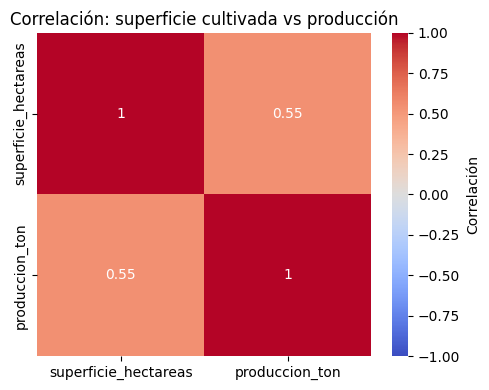

In [13]:
corr_matrix = superficie_produccion[['superficie_hectareas', 'produccion_ton']].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    cbar_kws={'label': 'Correlación'}
)
plt.title('Correlación: superficie cultivada vs producción')
plt.tight_layout()
plt.show()

##### Al hacer un gráfico de correlación tomando en cuenta más variables hemos descubierto que el rendimiento está estrechamente correlacionado a la producción. Una vez resolvamos la cuestión propuesta estudiaremos este caso.

<Axes: >

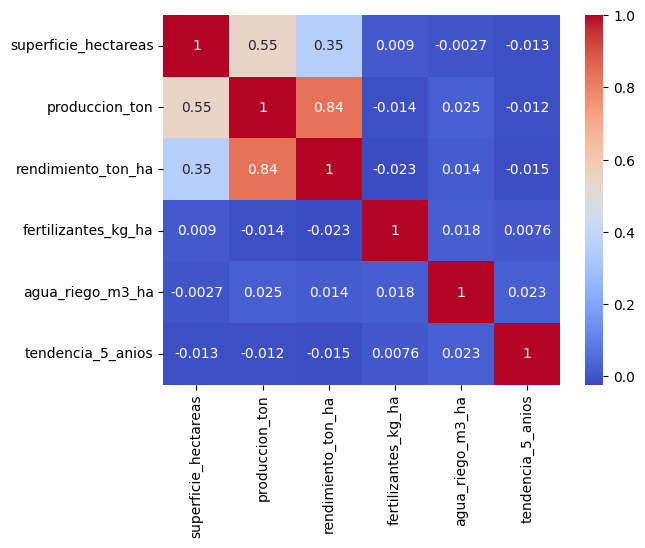

In [26]:
vars_estudio = [
    'superficie_hectareas',
    'produccion_ton',
    'rendimiento_ton_ha',
    'fertilizantes_kg_ha',
    'agua_riego_m3_ha',
    'tendencia_5_anios'
]
sub = datasets['produccion_agricola'][vars_estudio].dropna()
sns.heatmap(sub.corr(), annot=True, cmap='coolwarm')

##### El scatterplot confirma que a mayor hectáreas de cultivo, mayor es su producción. Nuevamente la caña de azucar sobresale del resto de cultivos en la gráfica, lo que ya nos puede ir indicando que es el cultivo que mejor rendimiento tiene.

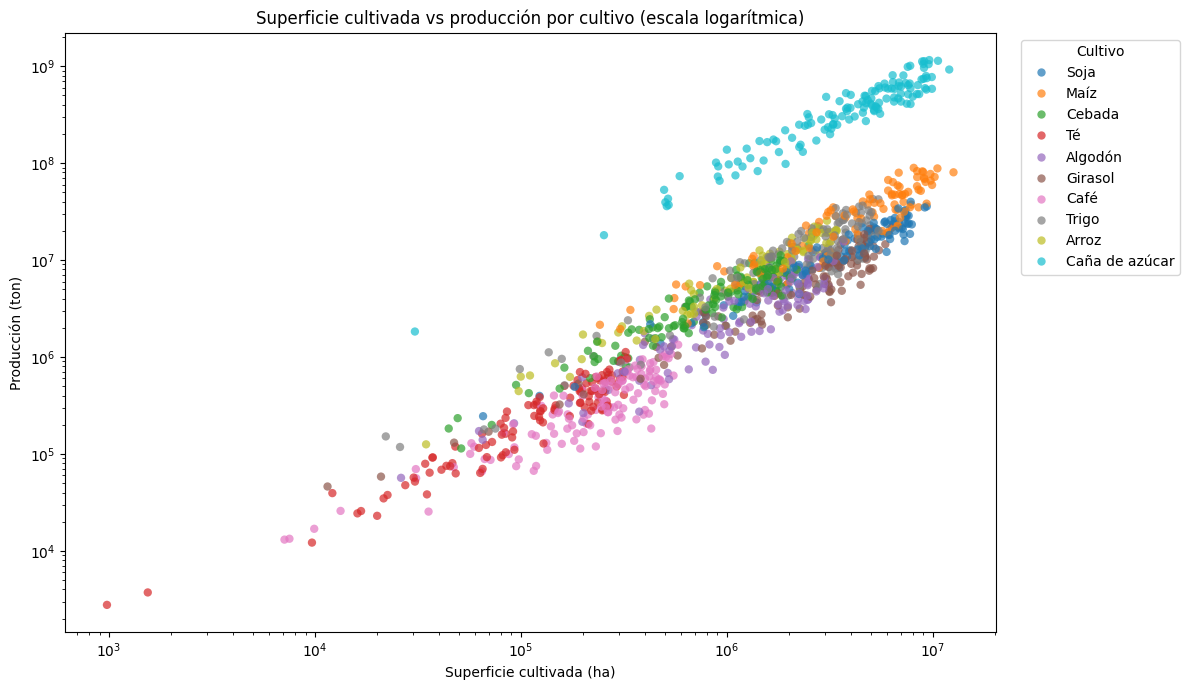

In [14]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=superficie_produccion,
    x='superficie_hectareas',
    y='produccion_ton',
    hue='cultivo',
    alpha=0.7,
    edgecolor='none'
)
plt.xscale('log')
plt.yscale('log')
plt.title('Superficie cultivada vs producción por cultivo (escala logarítmica)')
plt.xlabel('Superficie cultivada (ha)')
plt.ylabel('Producción (ton)')
plt.legend(title='Cultivo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

##### Al trazar una línea sobre el gráfico anterior podemos comprobar que la relación es consistente y se ajusta bastante a los datos. Se puede comprobar como la caña de azúcar sobresale, casi como un outlier, ya que produce mucho más que el resto.

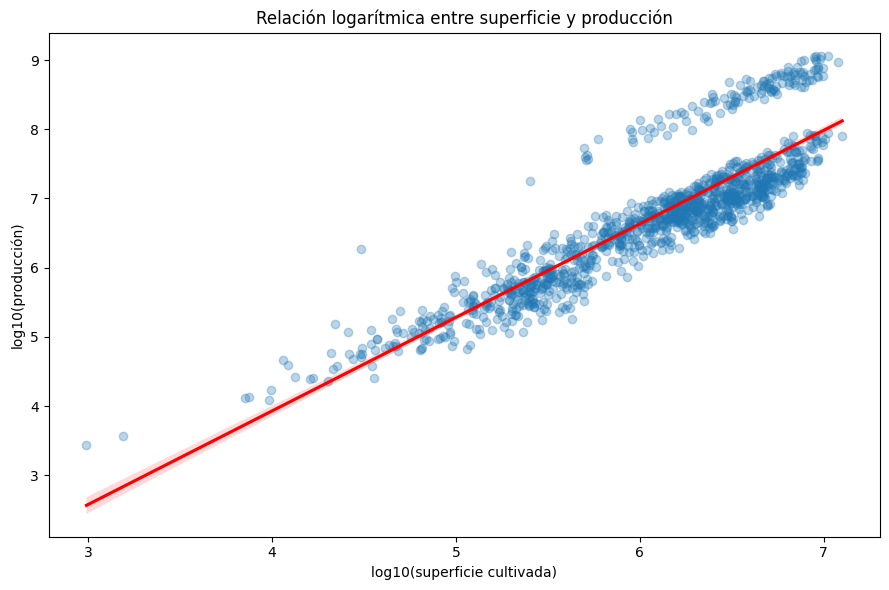

In [15]:
log_superficie = np.log10(superficie_produccion['superficie_hectareas'])
log_produccion = np.log10(superficie_produccion['produccion_ton'])

plt.figure(figsize=(9, 6))
sns.regplot(
    x=log_superficie,
    y=log_produccion,
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)
plt.title('Relación logarítmica entre superficie y producción')
plt.xlabel('log10(superficie cultivada)')
plt.ylabel('log10(producción)')
plt.tight_layout()
plt.show()

##### Al estudiar también en este caso la correlación individual de cada cultivo, terminamos de asegurar que claramente la superficie afecta en gran medida a la producción de ese tipo de cultivo.

In [23]:
corr_por_cultivo_superficie = []
for cultivo, grupo in superficie_produccion.groupby('cultivo'):
    corr = grupo['superficie_hectareas'].corr(grupo['produccion_ton'])
    corr_por_cultivo_superficie.append({'cultivo': cultivo, 'correlacion': corr, 'muestras': len(grupo)})

corr_por_cultivo_superficie = pd.DataFrame(corr_por_cultivo_superficie).sort_values('correlacion', ascending=False)
print(corr_por_cultivo_superficie)

          cultivo  correlacion  muestras
1           Arroz     0.930776        90
7            Soja     0.926807       110
3  Caña de azúcar     0.897172       130
4          Cebada     0.880106       140
9              Té     0.879218       110
6            Maíz     0.875522       110
5         Girasol     0.872805       120
0         Algodón     0.849956       120
2            Café     0.788033       130
8           Trigo     0.784814       140


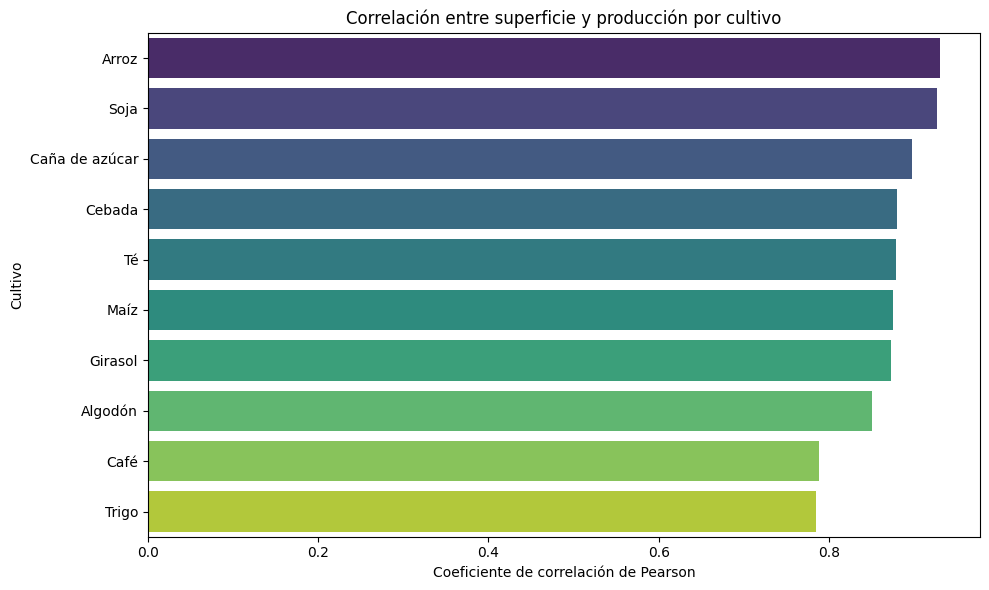

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=corr_por_cultivo_superficie,
    x='correlacion',
    y='cultivo',
    hue='cultivo',
    palette='viridis',
    dodge=False,
    legend=False
)
plt.title('Correlación entre superficie y producción por cultivo')
plt.xlabel('Coeficiente de correlación de Pearson')
plt.ylabel('Cultivo')
plt.tight_layout()
plt.show()

##### **Conclusión**: Se ha confirmado una correlación positiva en este caso, por lo que podemos asegurar que a mayor superficie cultivada, mayor es también la producción que obtenemos.

### 3.3 ¿?